# EDA: BreastMNIST

Ultrassom de mama, classificação binária entre normal/benigno e maligno. O menor
subset do MedMNIST.

Consome `results/`. Não produz artefato.

In [1]:
RAIZ <- "../../results/_smoke"
DATASET <- "medmnist-breastmnist-28"

suppressMessages(devtools::load_all("../../analysis", quiet = TRUE))
suppressMessages({
  library(ggplot2)
  library(dplyr)
})
options(repr.plot.width = 9, repr.plot.height = 4.5)

eda <- read_dataset_eda(DATASET, RAIZ)
s <- eda$summary
ex <- eda$examples
treino <- filter(ex, split == "train")
feats <- c("mean_intensity", "std_intensity", "nonzero_frac")

## 1. O tamanho é o problema

In [2]:
data.frame(
  campo = c("classes", "canais", "resolução", "treino", "validação", "teste"),
  valor = c(
    s$num_classes, s$in_channels, paste(s$resolution, collapse = "x"),
    s$n_examples$train, s$n_examples$val, s$n_examples$test
  )
)

campo,valor
<chr>,<chr>
classes,2
canais,1
resolução,28x28
treino,546
validação,78
teste,156


546 exemplos de treino, contra 50 mil no MNIST. Duas consequências:

In [3]:
n_val <- s$n_examples$val
n_test <- s$n_examples$test
cat(sprintf("validação: %d exemplos → 1 acerto vale %.2f pp\n", n_val, 100 / n_val))
cat(sprintf("teste:     %d exemplos → 1 acerto vale %.2f pp\n", n_test, 100 / n_test))

# IC binomial (Wilson) para uma acurácia hipotética de 80% em cada split
for (n in c(n_val, n_test)) {
  ci <- prop.test(round(0.80 * n), n)$conf.int
  cat(sprintf("acurácia de 80%% em n=%d: IC95%% [%.1f%%, %.1f%%] (largura %.1f pp)\n",
              n, 100 * ci[1], 100 * ci[2], 100 * (ci[2] - ci[1])))
}

validação: 78 exemplos → 1 acerto vale 1.28 pp


teste:     156 exemplos → 1 acerto vale 0.64 pp


acurácia de 80% em n=78: IC95% [68.5%, 87.5%] (largura 18.9 pp)
acurácia de 80% em n=156: IC95% [72.8%, 85.9%] (largura 13.1 pp)


O split de validação tem 78 exemplos. A incerteza de uma estimativa nesse tamanho
passa de 15 pontos percentuais: diferenças de 2 a 3 pp entre configurações são
indistinguíveis de ruído. O multi-seed separa as duas coisas.

## 2. Balanço: o piso é alto

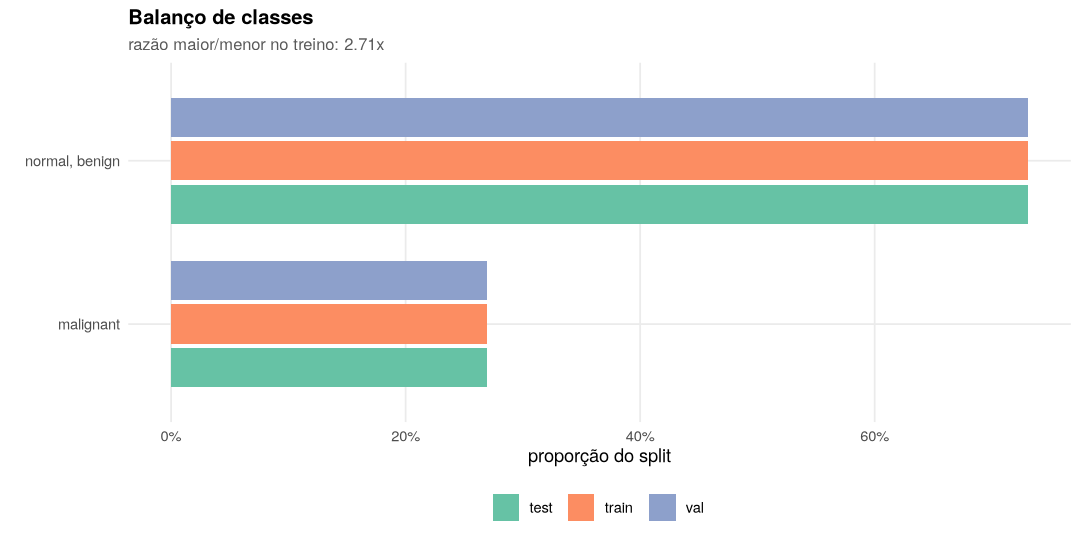

In [4]:
plot_class_balance(eda)

In [5]:
freq <- count(treino, class_name) |> mutate(p = n / sum(n)) |> arrange(desc(p))
print(as.data.frame(mutate(freq, p = sprintf("%.1f%%", 100 * p))))

cat(sprintf("\ndesbalanço: %.2fx\n", s$train_imbalance_ratio))
cat(sprintf("prever sempre '%s': %.1f%% de acurácia\n",
            freq$class_name[1], 100 * freq$p[1]))

      class_name   n     p
1 normal, benign 399 73.1%
2      malignant 147 26.9%



desbalanço: 2.71x


prever sempre 'normal, benign': 73.1% de acurácia


Um modelo que sempre responde "normal, benigno" acerta 73% e erra todos os casos
malignos, que são os que importam clinicamente.

A leitura exige balanced accuracy (média dos recalls) ou recall da classe maligna.
Ambas saem das predições exportadas, sem retreinar.

## 3. As imagens

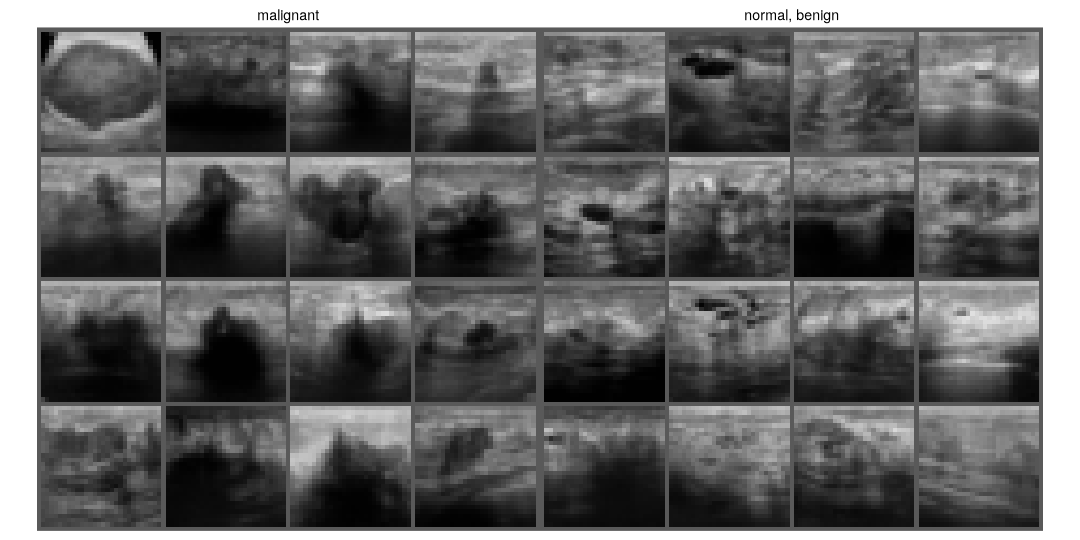

In [6]:
montage_grid(eda, root = RAIZ, ncol = 2)

Ultrassom: textura granulada, contorno difuso, sem cor. O sinal que separa as
classes está na forma e na textura da lesão, não no brilho geral.

## 4. Estatística de pixel não separa nada

In [7]:
# factor() é obrigatório: sem ele o lm faria regressão no valor numérico do
# rótulo em vez de ANOVA por classe.
r2 <- sapply(feats, function(v) {
  summary(lm(as.formula(paste(v, "~ factor(class_name)")), data = treino))$r.squared
})
round(r2, 4)

mean_intensity  std_intensity   nonzero_frac 
        0.0226         0.0183         0.0015

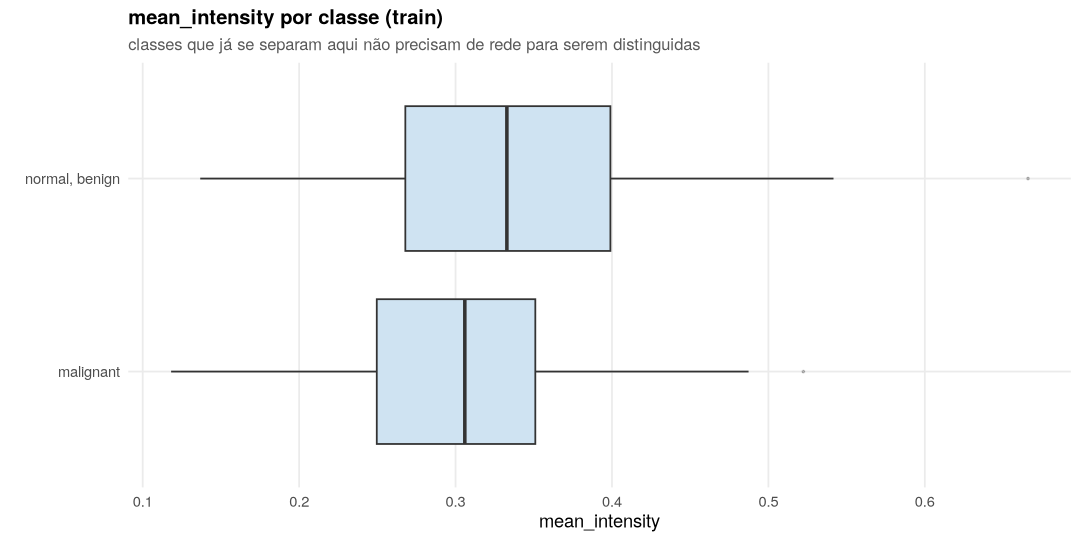

In [8]:
plot_feature_by_class(eda, "mean_intensity", "train")

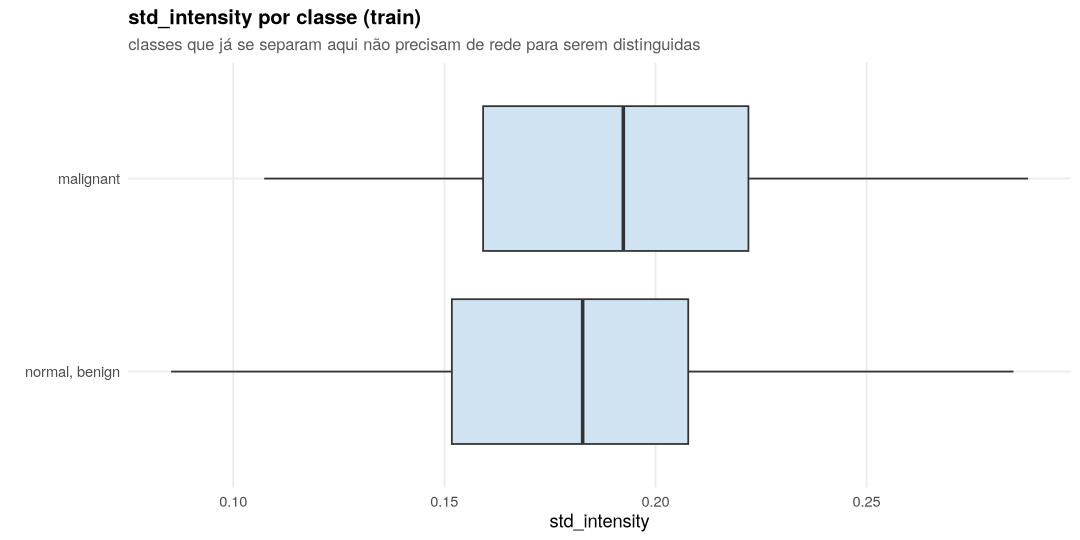

In [9]:
plot_feature_by_class(eda, "std_intensity", "train")

R² abaixo de 0,03 nas três features. No MNIST a quantidade de tinta explicava 46%
da variância; aqui a classe não se reflete em estatística global de pixel.

`nonzero_frac` fica em ~99,98%: ultrassom não tem fundo preto, cada pixel carrega
sinal. A feature mais informativa do MNIST é constante aqui. Feature de pixel não
é transferível entre domínios.

Não há atalho trivial: o modelo precisa aprender textura espacial.

In [10]:
# Confirmando pelo caminho mais direto: um classificador de centroide nessas três
# features consegue superar o chute na classe majoritária?
centroides <- treino |> group_by(class_name) |> summarise(across(all_of(feats), mean), .groups = "drop")
teste <- filter(ex, split == "test")
sds <- apply(as.matrix(treino[, feats]), 2, sd)
M <- sweep(as.matrix(teste[, feats]), 2, sds, "/")
C <- sweep(as.matrix(centroides[, feats]), 2, sds, "/")
dists <- sapply(seq_len(nrow(C)), function(i) rowSums((M - rep(C[i, ], each = nrow(M)))^2))
pred <- centroides$class_name[apply(dists, 1, which.min)]

cat(sprintf("centroide em 3 features: %.1f%% de acurácia\n", 100 * mean(pred == teste$class_name)))
cat(sprintf("chute na classe maior:   %.1f%%\n", 100 * max(freq$p)))
cat(sprintf("balanced accuracy do centroide: %.1f%%\n",
            100 * mean(sapply(unique(teste$class_name), function(k)
              mean(pred[teste$class_name == k] == k)))))

centroide em 3 features: 62.8% de acurácia


chute na classe maior:   73.1%


balanced accuracy do centroide: 59.5%


O centroide fica abaixo do chute na classe majoritária: distribui predições entre
as duas classes usando um sinal que não existe, trocando acertos garantidos na
classe maior por erros. Balanced accuracy de 59,5%, pouco acima do aleatório
depois de corrigir o desbalanço.

É o piso honesto. O que a rede entregar acima disso vem de textura espacial.

## 5. Os splits são comparáveis?

In [11]:
ex |>
  group_by(split) |>
  summarise(n = n(), across(all_of(feats), mean), .groups = "drop")

split,n,mean_intensity,std_intensity,nonzero_frac
<chr>,<int>,<dbl>,<dbl>,<dbl>
test,156,0.3359925,0.1789072,0.9997302
train,546,0.3275805,0.1829409,0.9998271
val,78,0.3387621,0.1867158,1.0000000


In [12]:
# Mais importante que a média de pixel: a proporção de classes se mantém?
ex |>
  count(split, class_name) |>
  group_by(split) |>
  mutate(p = sprintf("%.1f%%", 100 * n / sum(n))) |>
  ungroup() |>
  tidyr::pivot_wider(id_cols = class_name, names_from = split, values_from = p)

class_name,test,train,val
<chr>,<chr>,<chr>,<chr>
malignant,26.9%,26.9%,26.9%
"normal, benign",73.1%,73.1%,73.1%


O MedMNIST publica os três splits, então não há sorteio nosso envolvido. A
proporção de classes é idêntica nos três (26,9% / 73,1%): o split original foi
estratificado, a validação reproduz o regime de classes do teste, e selecionar
modelo nela não introduz viés de prevalência.

## O que fica

In [13]:
cat(sprintf("- %d exemplos de treino: regime de amostra pequena\n", s$n_examples$train))
ci_val <- prop.test(round(0.80 * n_val), n_val)$conf.int
cat(sprintf("- validação com %d exemplos: IC de %.0f pp, diferenças pequenas são ruído\n",
            n_val, 100 * (ci_val[2] - ci_val[1])))
cat(sprintf("- piso de acurácia: %.1f%% (prever sempre a classe maior)\n", 100 * max(freq$p)))
cat(sprintf("- R² máximo em estatística de pixel: %.3f (sem atalho trivial)\n", max(r2)))
cat("- splits estratificados: validação reproduz a prevalência do teste\n")
cat("- métrica a reportar: balanced accuracy ou recall de 'malignant', nunca acurácia\n")

- 546 exemplos de treino: regime de amostra pequena


- validação com 78 exemplos: IC de 19 pp, diferenças pequenas são ruído


- piso de acurácia: 73.1% (prever sempre a classe maior)


- R² máximo em estatística de pixel: 0.023 (sem atalho trivial)


- splits estratificados: validação reproduz a prevalência do teste


- métrica a reportar: balanced accuracy ou recall de 'malignant', nunca acurácia
